# **Reproduction and Extensions of**
## *An Analysis of Model-Based Interval Estimation for Markov Decision Processes*

**Course:** Seminar Advanced Topics in Reinforcement Learning  
**Professor:** Christos Dimitrakakis  
**Supervisor:** Victor Villin  
**Students:** Allizha Theiventhiram, Aurélie Wasem, Boris Verdecia Echarte, Rithika Shyam Kumar

---

## **Paper Reference**

**Strehl, A. L., & Littman, M. L. (2008).**  
>[*An Analysis of Model-Based Interval Estimation for Markov Decision Processes*](https://www.sciencedirect.com/science/article/pii/S0022000008000767?ref=pdf_download&fr=RR-2&rr=9e42619f7ebf6aa0#aep-abstract-id7)

Journal of Computer and System Sciences, 74(8), pages 1309–1331.  

### **Authors**

- **Alexander L. Strehl** — Yahoo! Inc., Sunnyvale, CA, USA  
- **Michael L. Littman** — Computer Science Department, Rutgers University, NJ, USA  

---
## **Objectives**
>- understand the theoretical foundations of optimism-based exploration in MDPs,
>- implement and compare MBIE, MBIE-EB, and baseline algorithms such as **E3** and **R-max**,
>-  reproduce benchmark experiments (e.g., RiverSwim and SixArms),
>- and explore possible extensions, including alternative exploration strategies or more challenging environments.

This work aims to provide both a theoretical and empirical understanding of efficient exploration in reinforcement learning.

---

## Structure of the Notebook

1. **Imports**
2. **Environments** — RiverSwim and SixArms
3. **Value Iteration** — functions used by all four algorithms
4. **Algorithms** — MBIE, MBIE-EB, R-Max and E3
5. **Run helpers** — `runs()`, `plot_bar()`, `plot_curves()`
6. **Reproduction** — RiverSwim and SixArms bar charts (Figures 2 & 3 of the paper)
7. **Extension 1** — Learning curves: full cumulative reward trajectory over time
8. **Extension 2** — Sensitivity to m: how the visit threshold affects all four algorithms
9. **Extension 3** — Sensitivity to A and B: confidence interval width heatmap for MBIE
10. **Extension 4** — Sensitivity to γ: discount factor sweep across all algorithms
11. **Extension 5** — FrozenLake 8×8: benchmarking on a new stochastic environment

---


## 1. Imports

In [ ]:
# Standard library
import math
from collections import defaultdict

# Third-party
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Gymnasium (install if needed)
# !pip install gymnasium
import gymnasium as gym

## 2. Environments

We reproduce the two benchmark MDPs from Section 6 of Strehl & Littman (2008).
Both are small finite MDPs chosen to stress-test specific exploration strategies.

### RiverSwim
6 states arranged in a chain. The agent starts near the left end and can swim
left (easy, deterministic) or right (hard, stochastic — fights the river current).

- **Left action:** always succeeds, small reward of 5 at state 0
- **Right action:** succeeds with prob 0.3 (moves forward), fails with prob 0.7 (stays)
- **Big reward:** expected 3000 at state 5 (raw reward 10000 × prob 0.3)

The challenge: the agent must commit to a long sequence of rightward actions
against the current before discovering the large reward. Naive exploration fails.

### SixArms
7 states: one hub (state 0) connected to 6 rooms (states 1–6).
Each action at the hub pulls one arm, entering the corresponding room with
some probability.

- **Arm probabilities:** [1.0, 0.15, 0.10, 0.05, 0.03, 0.01]
- **Room rewards:** [50, 133, 300, 800, 1660, 6000]
- **Key structure:** higher probability arms give lower rewards

The agent must learn which arms are worth visiting — arms with low success
probability give the highest payoff, so greedy exploration based on observed
frequency severely underestimates the best arms.

In [2]:
class MDP:
    """
    Generic finite Markov Decision Process.

    Notation:
        P[s, a, s_next] = probability of transitioning to s_next
        R[s, a]         = expected immediate reward for taking action a in state s

    This class is intentionally simple because the paper experiments use small,
    tabular environments.
    """
    def __init__(self, n_states: int, n_actions: int):
        self.n_states = n_states
        self.n_actions = n_actions
        self.state = 0

        # Transition matrix: shape (S, A, S)
        self.P = np.zeros([n_states, n_actions, n_states])

        # Expected reward matrix: shape (S, A)
        self.R = np.zeros([n_states, n_actions])

    def get_transition_probability(self, state: int, action: int, next_state: int) -> float:
        """
        Return P(next_state | state, action)
        """
        return self.P[state, action, next_state]

    def get_transition_probabilities(self, state: int, action: int) -> list[float]:
        """
        Return the full transition distribution P(. | state, action)
        """
        return self.P[state, action]

    def generate_state(self, state: int, action: int) -> int:
        """
        Sample the next state according to P(. | state, action)
        """
        return np.random.choice(self.n_states, p=self.P[state, action])

    def get_reward(self, state: int, action: int) -> float:
        """
        Return the expected immediate reward R(state, action)
        """
        return self.R[state, action]

    def get_rewards(self, state: int) -> list[int]:
        """
        Return all action rewards available from a given state
        """
        return self.R[state]

    def step(self, action: np.intp) -> tuple[int, float, bool, dict]:
        """
        Execute one environment step.

        The reward is taken from R(s, a), then the next state is sampled from
        the transition distribution P(. | s, a).
        """
        reward = self.get_reward(self.state, action)
        self.state = self.generate_state(self.state, action)

        done = False

        return self.state, reward, done, {}

    def reset(self):
        """
        Reset the environment to its default initial state
        """
        self.state = 0
        return self.state


class RiverSwimMDP(MDP):
    """
    RiverSwim environment

    States:
        0 = far-left low-reward state
        5 = far-right high-reward state

    Actions:
        0 = swim left
        1 = swim right
    """
    def __init__(self):
        super().__init__(6, 2)

        # Transition matrix P[s, a, s_next]
        self.P = np.array(
            [   # action 0                       # action 1
                [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.7, 0.3, 0.0, 0.0, 0.0, 0.0]],  # state 0
                [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.1, 0.6, 0.3, 0.0, 0.0, 0.0]],  # state 1
                [[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.1, 0.6, 0.3, 0.0, 0.0]],  # state 2
                [[0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.1, 0.6, 0.3, 0.0]],  # state 3
                [[0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.1, 0.6, 0.3]],  # state 4
                [[0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.7, 0.3]],  # state 5
            ],
            dtype=float,
        )

        # Expected rewards R[s, a]
        self.R = np.array(
            [
                [5.0, 0.0],
                [0.0, 0.0],
                [0.0, 0.0],
                [0.0, 0.0],
                [0.0, 0.0],
                [0.0, 3_000.0],
            ],
            dtype=float,
        )

        self.reset()

    def reset(self):
        """
        Reset RiverSwim.

        In the paper, the agent starts in state 1 or 2 with equal probability.
        """
        self.state = np.random.choice([1, 2])
        return self.state


class SixArmsMDP(MDP):
    """
    SixArms environment

    State 0 is the central decision state.
    Each action tries to enter one of six arms.

    Easier arms have higher success probabilities but smaller rewards.
    Harder arms have lower success probabilities but larger rewards.
    """
    def __init__(self):
        super().__init__(7, 6)

        # Transition matrix P[s, a, s_next]
        self.P = np.array(
            [
                # State 0: central decision state
                [
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [0.85, 0.00, 0.15, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [0.90, 0.00, 0.00, 0.10, 0.00, 0.00, 0.00],  # action 2
                    [0.95, 0.00, 0.00, 0.00, 0.05, 0.00, 0.00],  # action 3
                    [0.97, 0.00, 0.00, 0.00, 0.00, 0.03, 0.00],  # action 4
                    [0.99, 0.00, 0.00, 0.00, 0.00, 0.00, 0.01],  # action 5
                ],

                # State 1: low-reward arm
                [
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 2
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 3
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 4
                    [0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 5
                ],

                # State 2
                [
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 2
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 3
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 4
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 5
                ],

                # State 3
                [
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00],  # action 2
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 3
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 4
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 5
                ],

                # State 4
                [
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 2
                    [0.00, 0.00, 0.00, 0.00, 1.00, 0.00, 0.00],  # action 3
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 4
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 5
                ],

                # State 5
                [
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 2
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 3
                    [0.00, 0.00, 0.00, 0.00, 0.00, 1.00, 0.00],  # action 4
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 5
                ],

                # State 6: highest-reward arm
                [
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 0
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 1
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 2
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 3
                    [1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00],  # action 4
                    [0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 1.00],  # action 5
                ],
            ],
            dtype=float,
        )

        # Expected reward matrix R[s, a]
        self.R = np.array(
            [
                [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                [50.0, 50.0, 50.0, 50.0, 0.0, 50.0],
                [0.0, 133.0, 0.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 300.0, 0.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 800.0, 0.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 1660.0, 0.0],
                [0.0, 0.0, 0.0, 0.0, 0.0, 6000.0],
            ],
            dtype=float,
        )

        self.reset()

    def reset(self):
        """
        Reset SixArms to the central decision state
        """
        self.state = 0
        return self.state

## 3. Value Iteration

Two value iteration functions are used:

**`q_value_iteration_w_ci`** — used by MBIE. Builds the most optimistic MDP within
the confidence interval on transitions, then runs Bellman updates. At each step it
shifts probability mass from the lowest-value next state to the highest-value one,
up to the CI width ε. This implements Eq. (6) from the paper.

**`q_value_iteration_mbie_eb`** — standard Bellman updates on the empirical model.
Used by MBIE-EB (with the exploration bonus baked into R_hat) and by the
internal models of R-Max and E3.

Both use a **doubling replan schedule** — value iteration is only triggered when
the visit count for the updated pair is a power of 2 (1, 2, 4, 8, ...).
This gives 25× fewer replans with negligible effect on policy quality.

In [3]:
# --------------------------- Q-VALUE ITERATION FOR MBIE (NON OPTIMIZED) ------------------------------------

def q_one_step_lookahead_w_ci(mdp,Q_tild, R_tild, T_hat, T_ci, R_max, count_sa, state, gamma):
  """
  Perform one optimistic Bellman update for one state in MBIE.

  MBIE uses confidence intervals on transitions. The idea is to move probability
  mass toward the currently best next state, while removing mass from the worst
  next states. This implements optimism in the face of uncertainty.
  """
  V = np.max(Q_tild, axis=1)

  for action in range(mdp.n_actions):
      q_sum = 0

      if count_sa[state, action] == 0:
        # Unvisited state-action pairs are initialized optimistically
        q_sum = R_max / (1 - gamma)

      else:
        # Start from the empirical transition model
        T_tild = np.copy(T_hat[state, action])
        epsilon = T_ci[state, action]
        best_next_state = np.argmax(V)

        # Add optimistic mass to the best next state
        delta = min(epsilon / 2, 1.0 - T_tild[best_next_state])
        T_tild[best_next_state] += delta

        # Remove the same mass from the worst next states
        to_remove = delta
        sorted_states = np.argsort(V)

        for next_state in sorted_states:
          if to_remove <= 0:
            break

          if next_state == best_next_state:
              continue

          # Take as much as possible without dropping probability below 0
          remove_amount = min(to_remove, T_tild[next_state])
          T_tild[next_state] -= remove_amount
          to_remove -= remove_amount

        reward = R_tild[state, action]
        q_sum = reward + gamma * np.sum(T_tild * V)

      Q_tild[state, action] = q_sum

  vmax = R_max / (1 - gamma)
  Q_tild[state] = np.clip(Q_tild[state], 0, vmax)
    
  return Q_tild


def q_value_iteration_w_ci(mdp, Q_tild, R_tild, T_hat, T_ci, R_max,count_sa, gamma: float = 0.95, theta: float = 0.01):
    """
    Run value iteration for MBIE using optimistic confidence intervals.
    """
    V = np.zeros([mdp.n_states])
    delta = 1

    for i in range(10_000):
        delta = 0

        for state in range(mdp.n_states):
            Q_tild = q_one_step_lookahead_w_ci(mdp, Q_tild, R_tild, T_hat, T_ci, R_max,count_sa, state, gamma)

            update = np.max(Q_tild[state])
            delta = max(delta, np.abs(update - V[state]))
            V[state] = update
        
        Q_tild = np.clip(Q_tild, 0, R_max / (1 - gamma))
        if delta < theta:
           break

    return V, Q_tild


# --------------------------- Q-VALUE ITERATION FOR MBIE-EB ---------------------------

def q_value_iteration_mbie_eb(mdp, Q_tild, R_hat, T_hat, count_sa, max_value, gamma=0.95, theta=0.01):
    R_model = np.copy(R_hat)
    T_model = np.copy(T_hat)

    for s in range(mdp.n_states):
        for a in range(mdp.n_actions):
            if count_sa[s, a] == 0:
                R_model[s, a]    = max_value
                T_model[s, a, s] = 1.0

    V = np.zeros(mdp.n_states)
    delta = 1

    i = 0
    while i < 10_000:
        delta = 0
        for state in range(mdp.n_states):
            for action in range(mdp.n_actions):
                Q_tild[state, action] = (R_model[state, action] + gamma * np.dot(T_model[state, action], V))
            update   = np.max(Q_tild[state])
            delta    = max(delta, np.abs(update - V[state]))
            V[state] = update
        i += 1
        if delta < theta:
            break
    return V, Q_tild

## 4. Algorithms

All four algorithms share the core principle of **optimism in the face of uncertainty**:
unknown state-action pairs are assumed to be maximally rewarding until enough data
is collected to estimate them accurately.

The key quantity is **vmax = R_max / (1 − γ)** — the maximum possible discounted
return. Unknown pairs are initialised to this value, making them always attractive
to explore. Once a pair accumulates enough visits, the fictitious reward is replaced
by the empirical estimate and the optimism fades.

### MBIE — Model-Based Interval Estimation

**Paper:** Strehl & Littman (2008), Section 3.1 — Theorem 1

MBIE maintains confidence intervals on both the reward **R(s,a)** and the
transition distribution **T(s,a)**. At each replan it solves the most optimistic
MDP within those intervals:

$$\tilde{Q}(s,a) = \max_{\tilde{R} \in CI(R)} \tilde{R}(s,a) + \max_{\tilde{T} \in CI(T)} \gamma \sum_{s'} \tilde{T}(s'|s,a) \max_{a'} \tilde{Q}(s',a')$$

The reward CI width is `A × R_max / √n` and the transition CI width is `B / √n`,
both shrinking as visits `n` increase. Unknown pairs (n=0) are initialised to vmax.

**Parameters:** A=0.3, B=0 (RiverSwim) · A=0.3, B=0.08 (SixArms)

In [4]:
class MBIE:
    def __init__(
        self,
        env: MDP,
        max_reward: float,
        discount_factor: float,
        A: float,
        B: float,
        m=math.inf,
    ):
        self.env = env
        self.discount_factor = discount_factor

        self.max_reward = max_reward
        self.max_value = max_reward / (1 - self.discount_factor)
        self.A = A
        self.B = B
        self.m = m

        self.n_states = env.n_states
        self.n_actions = env.n_actions
        self.count_sas = np.zeros([self.n_states, self.n_actions, self.n_states])
        self.count_sa = np.zeros([self.n_states, self.n_actions])
        self.Q_tild = np.full([self.n_states, self.n_actions], self.max_value)
        self.R_hat = np.zeros([self.n_states, self.n_actions])
        self.R_tild = np.zeros([self.n_states, self.n_actions])
        self.T_hat = np.zeros([self.n_states, self.n_actions, self.n_states])
        self.T_ci = np.zeros([self.n_states, self.n_actions])
        self.R_sum = np.zeros([self.n_states, self.n_actions])

    def _update_reward(self, s, a):
        reward_ci = self.A * self.max_reward / np.sqrt(self.count_sa[s, a])
        reward = self.R_sum[s, a] / self.count_sa[s, a]
        self.R_hat[s, a] = reward
        self.R_tild[s, a] = reward + reward_ci

    def _update_transition(self, s, a, next_s):
        prob = self.count_sas[s, a, next_s] / self.count_sa[s, a]
        self.T_hat[s, a, next_s] = prob

    def _update_transition_ci(self, s, a):
        trans_ci = self.B * (1 / np.sqrt(self.count_sa[s, a]))
        self.T_ci[s, a] = trans_ci

    def _build_estimates(self, state, action):
        if self.count_sa[state, action] == 0:
            pass
        else:
            self._update_reward(state, action)
            self._update_transition_ci(state, action)
            for next_s in range(self.n_states):
                self._update_transition(state, action, next_s)

    def run(self, experiments):
        state = self.env.reset()
        action = np.argmax(self.Q_tild[state])
        curve = np.zeros(experiments)
        total = 0.0
        self.total_reward = 0.0
        real_counts = np.zeros([self.n_states, self.n_actions])

        for t in range(experiments):
            next_state, reward, _, _ = self.env.step(action)

            if self.count_sa[state, action] < self.m:
                self.count_sa[state, action] += 1
                if self.count_sas[state, action, next_state] < self.m:
                    self.count_sas[state, action, next_state] += 1
                self.R_sum[state, action] += reward

            self.total_reward += reward
            self._build_estimates(state, action)

            real_counts[state, action] += 1
            n = int(real_counts[state, action])
            if n > 0 and (n == 1 or (n & (n - 1)) == 0) and n <= self.m:
                _, self.Q_tild = q_value_iteration_w_ci(
                    self.env, self.Q_tild, self.R_tild, self.T_hat,
                    self.T_ci, self.max_reward, self.count_sa,
                    gamma=self.discount_factor,
                )

            total += reward
            curve[t] = total
            action = np.argmax(self.Q_tild[next_state])
            state = next_state

        return curve
    
    def cumulative_reward(self):
        return self.total_reward

### MBIE-EB — MBIE with Exploration Bonus

**Paper:** Strehl & Littman (2008), Section 3.2 — Theorem 2

MBIE-EB is a simpler variant that adds an exploration bonus directly to the
empirical reward estimate, avoiding the confidence interval optimisation on transitions:

$$\tilde{Q}(s,a) = \hat{R}(s,a) + \frac{\beta}{\sqrt{n(s,a)}} + \gamma \sum_{s'} \hat{T}(s'|s,a) \max_{a'} \tilde{Q}(s',a')$$

where **β = C × R_max**. The bonus shrinks as visits increase, gradually replacing
optimism with the true empirical value. Unknown pairs (n=0) are initialised to vmax.

Compared to MBIE: simpler to implement, cheaper to compute, same PAC-MDP guarantee.

**Parameters:** C=0.4 (RiverSwim) · C=0.8 (SixArms)

In [5]:
class MBIE_EB(MBIE):
    def __init__(self, env: MDP, max_reward: float,
                 discount_factor: float, C: float, m=math.inf):
        super().__init__(env, max_reward, discount_factor, 0, 0, m=m)
        self.C = C

    def _update_reward(self, s, a):
        bonus = self.C * self.max_reward / np.sqrt(self.count_sa[s, a])
        self.R_hat[s, a] = self.R_sum[s, a] / self.count_sa[s, a] + bonus

    def _build_estimates(self, state, action):
        if self.count_sa[state, action] == 0:
            return
        self._update_reward(state, action)
        for next_s in range(self.n_states):
            self._update_transition(state, action, next_s)

    def run(self, experiments):
        state  = self.env.reset()
        action = np.argmax(self.Q_tild[state])
        curve  = np.zeros(experiments)
        total  = 0.0
        self.total_reward = 0.0
        real_counts = np.zeros([self.n_states, self.n_actions])

        for t in range(experiments):
            next_state, reward, _, _ = self.env.step(action)

            if self.count_sa[state, action] < self.m:
                self.count_sa[state, action] += 1
                if self.count_sas[state, action, next_state] < self.m:
                    self.count_sas[state, action, next_state] += 1
                self.R_sum[state, action] += reward

            self.total_reward += reward
            real_counts[state, action] += 1
            self._build_estimates(state, action)

            n = int(real_counts[state, action])
            if n > 0 and (n == 1 or (n & (n - 1)) == 0) and n <= self.m:
                _, self.Q_tild = q_value_iteration_mbie_eb(
                    self.env, self.Q_tild, self.R_hat, self.T_hat,
                    self.count_sa, self.max_value, gamma=self.discount_factor,
                )

            total   += reward
            curve[t] = total
            action   = np.argmax(self.Q_tild[next_state])
            state    = next_state

        return curve

    def cumulative_reward(self):
        return self.total_reward

### R-Max — Brafman & Tennenholtz (2002)

Referenced in Strehl & Littman (2008) Section 1.4 as the baseline PAC-MDP algorithm.

R-Max uses a hard binary threshold: a state-action pair is either **unknown** (fewer
than m visits) or **known** (at least m visits).

- **Unknown pairs:** reward = R_max, transition = self-loop → vmax in the model
- **Known pairs:** use empirical reward and transition estimates
- **Replanning:** only triggered when a pair transitions from unknown to known

This is simpler than MBIE but less adaptive — it cannot partially exploit a pair
it has visited 14 times out of m=16, whereas MBIE's CI is already quite tight.

**Parameters:** m=16 (RiverSwim) · m=6 (SixArms)

In [6]:
class RMax:
  """
    R-Max algorithm (Brafman & Tennenholtz, 2002).

    Core idea (Section 6, Strehl & Littman 2008, footnote 12):
        Every state-action pair (s,a) is classified as "known" or "unknown".
        - Unknown (fewer than m visits): fictitious reward = R_max and
          fictitious transition = stay in s. This makes unknown pairs
          look maximally attractive, naturally driving exploration.
        - Known (at least m visits): use empirical estimates of R and T
          built from observed experience.

    At each update, R-Max solves its internal optimistic MDP via value
    iteration and follows the resulting optimal policy.

    Args:
        states    : list of states in the MDP
        actions   : list of actions in the MDP
        gamma     : discount factor (between 0 and 1)
        m         : visit threshold to declare (s,a) "known"
                    (m=16 for RiverSwim, m=6 for SixArms — Section 6)
        R_max     : fictitious reward for unknown pairs,
                    must be >= maximum possible reward in the true MDP
    """
  def __init__(self, n_states, n_actions, gamma, m, R_max):
      # Hyperparameters
      self.n_states = n_states
      self.n_actions = n_actions
      self.gamma = gamma
      self.m = m
      self.R_max = R_max

      # Current policy: action 1 everywhere by default
      # (updated as soon as a (s,a) pair becomes known)
      self.policy = np.ones(n_states, dtype=int)

      # Visit counter per (s,a) pair
      self.N = np.zeros((n_states, n_actions))

      # Transition counter (s,a) -> s'
      self.N_sas = np.zeros((n_states, n_actions, n_states))

      # Cumulative reward sum for (s,a)
      self.R_sum = np.zeros((n_states, n_actions))

  def _is_known(self, s, a):
    """
    Return True if (s,a) has been visited at least m times.
    """
    return self.N[s, a] >= self.m

  def _build_model(self):
    """
    Build the internal optimistic MDP used by R-Max.

      For each (s,a):
          - If known   : use empirical estimates R_hat(s,a) and T_hat(s'|s,a)
          - If unknown : fictitious reward R_max + fictitious transition
                          (stay in s), making this pair maximally attractive

      This construction is the core of R-Max — it forces the agent
      to explore unknown regions before exploiting known ones.

      Returns:
          P_model : internal MDP transitions, shape (S, A, S)
          R_model : internal MDP rewards, shape (S, A)
    """
    S, A = self.n_states, self.n_actions

    P = np.zeros((S, A, S))
    R = np.zeros((S, A))

    for s in range(S):
        for a in range(A):
            if self._is_known(s, a):
                # Empirical mean reward estimate
                R[s, a] = self.R_sum[s, a] / self.N[s, a]
                # Empirical transition probability estimate
                P[s, a] = self.N_sas[s, a] / self.N[s, a]
            else:
                # Optimism: fictitious maximum reward
                R[s, a] = self.R_max
                # Optimism: fictitious transition — agent stays in s
                P[s, a, s] = 1.0

    return P, R

  def _value_iteration(self, P, R, tol=0.01, max_iter=200):
    """
      Solve the internal optimistic MDP using value iteration.

      The goal is to compute an approximately optimal policy for the
      currently estimated model.

      Args:
          P        : transition probabilities, shape (S, A, S)
          R        : reward table, shape (S, A)
          tol      : stopping threshold for value convergence
          max_iter : maximum number of value iteration updates

      Returns:
          policy : best action for each state according to the optimistic MDP
    """
    V = np.zeros(self.n_states)

    for _ in range(max_iter):
        # Compute Q(s,a) = R(s,a) + gamma * sum_s' P(s'|s,a) V(s')
        Q = R + self.gamma * np.einsum('ijk,k->ij', P, V)

        # The value of a state is the value of its best action.
        V_new = Q.max(axis=1)

        if np.max(np.abs(V_new - V)) < tol:
            break
        V = V_new

    # Recompute Q-values using the final value function.
    Q = R + self.gamma * np.einsum('ijk,k->ij', P, V)

    # Select the greedy action for each state.
    policy = Q.argmax(axis=1)
    return policy

  def _update_policy(self):
      """
      Rebuild the optimistic model and recompute the policy.

      This is called only when a new (s,a) pair becomes known.
      """
      P, R = self._build_model()
      self.policy = self._value_iteration(P, R)

  def select_action(self, s):
      """
      Select the action prescribed by the current policy in state s.
      """
      return self.policy[s]

  def update(self, s, a, r, s2):
      """
      Update the empirical counters after observing one transition.

      Args:
          s  : current state
          a  : action taken
          r  : reward received
          s2 : next state

      R-Max only records data for a pair (s,a) until it becomes known.
      After N(s,a) reaches m, the empirical model is considered reliable
      enough and the policy is recomputed.
      """
      # Only collect samples while the pair is still unknown.
      if self.N[s, a] < self.m:

        # Count one additional visit to (s,a).
        self.N[s, a] += 1
        # Count the observed transition s --a--> s2.
        self.N_sas[s, a, s2] += 1
        # Add the observed reward to the cumulative reward sum.
        self.R_sum[s, a] += r

        # As soon as the pair becomes known, update the policy.
        if self.N[s, a] == self.m:
            self._update_policy()


class RMaxAgent:
    """
    Wrapper around the RMax model.

    This class connects the R-Max algorithm to an environment.
    It handles interaction with the environment, stores the total reward,
    and returns the cumulative reward curve for plotting.
    """
    def __init__(self, env, gamma, m, R_max):
        self.env = env
        self.model = RMax(
            env.n_states, env.n_actions, gamma, m, R_max
        )
        self.total_reward = 0.0

    def run(self, steps):
        """
        Run the R-Max agent in the environment for a fixed number of steps.

        Args:
            steps : number of interaction steps with the environment

        Returns:
            curve : cumulative reward after each time step
        """
        s     = self.env.reset()
        a     = self.model.select_action(s)
        curve = np.zeros(steps)
        total = 0.0

        for t in range(steps):
            # Execute the selected action in the environment.
            s2, r, _, _ = self.env.step(a)

            # Update the R-Max model with the observed transition.
            self.model.update(s, a, r, s2)

            # Update global and local cumulative rewards.
            self.total_reward += r
            total  += r

            # Save cumulative reward at this time step.
            curve[t] = total

            # Move to the next state.
            s = s2

            # Select next action according to the updated policy.
            a = self.model.select_action(s)

        return curve

    def cumulative_reward(self):
        """
        Return the total reward accumulated by the agent.
        """
        return self.total_reward

### E3 — Explicit Explore or Exploit (Kearns & Singh, 2002)

Referenced in Strehl & Littman (2008) Section 2 and compared in Section 6.

E3 maintains **two separate models and two separate policies** simultaneously:

- **Exploit model:** unknown pairs → reward 0, self-loop → policy *avoids* unknowns
- **Explore model:** unknown pairs → reward vmax, self-loop → policy *seeks* unknowns

At each timestep, E3 estimates the probability that the explore policy would reach
an unknown pair within H steps. If this escape probability exceeds a threshold,
it follows the explore policy; otherwise it exploits.

Unlike MBIE and R-Max which are always implicitly optimistic, E3 makes an
**explicit binary decision** at every step. In theory this is elegant; in practice
it is brittle — a bad batch of observations can cause the explore policy to stop
steering toward unknown territory, trapping the agent.

**Parameters:** m=16, thresh=0.01 (RiverSwim) · m=4, thresh=0.09 (SixArms)

In [7]:
class E3:
    """
    Explicit Explore or Exploit — Kearns & Singh (2002).
    Referenced in Strehl & Littman (2008) §2 and §6.

    Two separate models and two separate policies:
    - Exploit model: unknown (s,a) → reward 0, self-loop (agent avoids them)
    - Explore model: unknown (s,a) → reward vmax, self-loop (agent seeks them)

    At each step: estimate P(explore policy reaches unknown pair in H steps).
    If > thresh → follow explore policy. Else → follow exploit policy.

    """
    def __init__(self, states, actions, gamma,
                 m=16, thresh=0.01, R_max=10000.0,
                 H=20, n_escape_samples=10):
        self.states           = states
        self.actions          = actions
        self.gamma            = gamma
        self.m                = m
        self.thresh           = thresh
        self.R_max            = R_max
        self.vmax             = R_max / (1.0 - gamma)
        self.H                = H
        self.n_escape_samples = n_escape_samples

        self.n    = {s: {a: 0   for a in actions} for s in states}
        self.Rsum = {s: {a: 0.0 for a in actions} for s in states}
        self.Tcnt = {s: {a: defaultdict(int) for a in actions} for s in states}

        # Two separate Q-tables, both initialised optimistically
        self.Q_exploit = {s: {a: self.vmax for a in actions} for s in states}
        self.Q_explore = {s: {a: self.vmax for a in actions} for s in states}

    def _is_known(self, s, a):
        return self.n[s][a] >= self.m

    def _T_hat(self, s, a):
        n = self.n[s][a]
        if n == 0:
            return {}
        return {sp: c / n for sp, c in self.Tcnt[s][a].items()}

    def _value_iteration_exploit(self, max_iter=200, theta=0.01):
        """
        Value iteration for the exploitation model.
        Unknown pairs get reward 0 → policy avoids them.
        Updates ALL Q values on every iteration (not just best action).
        """
        V = {s: 0.0 for s in self.states}
        for _ in range(max_iter):
            V_new = {}
            for s in self.states:
                for a in self.actions:
                    if not self._is_known(s, a):
                        self.Q_exploit[s][a] = 0.0
                    else:
                        R  = self.Rsum[s][a] / self.n[s][a]
                        ev = sum(p * V.get(sp, 0.0)
                                 for sp, p in self._T_hat(s, a).items())
                        self.Q_exploit[s][a] = R + self.gamma * ev
                V_new[s] = max(self.Q_exploit[s].values())
            if max(abs(V_new[s] - V[s]) for s in self.states) < theta:
                break
            V = V_new

    def _value_iteration_explore(self, max_iter=200, theta=0.01):
        """
        Value iteration for the exploration model.
        Unknown pairs get reward vmax → policy seeks them.
        Updates ALL Q values on every iteration (not just best action).
        """
        V = {s: 0.0 for s in self.states}
        for _ in range(max_iter):
            V_new = {}
            for s in self.states:
                for a in self.actions:
                    if not self._is_known(s, a):
                        self.Q_explore[s][a] = self.vmax
                    else:
                        R  = self.Rsum[s][a] / self.n[s][a]
                        ev = sum(p * V.get(sp, 0.0)
                                 for sp, p in self._T_hat(s, a).items())
                        self.Q_explore[s][a] = R + self.gamma * ev
                V_new[s] = max(self.Q_explore[s].values())
            if max(abs(V_new[s] - V[s]) for s in self.states) < theta:
                break
            V = V_new

    def _replan(self):
        self._value_iteration_exploit()
        self._value_iteration_explore()

    def _escape_probability(self, s):
        """Monte Carlo estimate: follow explore policy for H steps, 
        count fraction of rollouts that hit an unknown pair."""
        hits = 0
        for _ in range(self.n_escape_samples):
            state = s
            for _ in range(self.H):
                a = max(self.actions, key=lambda a: self.Q_explore[state][a])
                if not self._is_known(state, a):
                    hits += 1
                    break
                T = self._T_hat(state, a)
                if not T:
                    break
                state = np.random.choice(list(T.keys()), p=list(T.values()))
        return hits / self.n_escape_samples

    def act(self, s):
        if self._escape_probability(s) > self.thresh:
            return max(self.actions, key=lambda a: self.Q_explore[s][a])
        return max(self.actions, key=lambda a: self.Q_exploit[s][a])

    def update(self, s, a, r, s2):
        if self.n[s][a] >= self.m:
            return
        self.n[s][a]        += 1
        self.Rsum[s][a]     += r
        self.Tcnt[s][a][s2] += 1
        # Replanning only at powers of 2 — 25x fewer replans, same result
        n = self.n[s][a]
        if n == 1 or (n & (n - 1)) == 0:
            self._replan()


class E3Agent:
    def __init__(self, env, gamma, m, thresh, R_max, n_escape_samples=10):
        self.env   = env
        self.model = E3(
            states=list(range(env.n_states)),
            actions=list(range(env.n_actions)),
            gamma=gamma, m=m, thresh=thresh, R_max=R_max,
            n_escape_samples=n_escape_samples
        )
        self.total_reward = 0.0

    def run(self, steps):
        s     = self.env.reset()
        curve = np.zeros(steps)
        total = 0.0

        for t in range(steps):
            a            = self.model.act(s)
            s2, r, _, _  = self.env.step(a)
            self.model.update(s, a, r, s2)
            self.total_reward += r
            total   += r
            curve[t] = total
            s = s2

        return curve

    def cumulative_reward(self):
        return self.total_reward

## 5. Run helpers

In [8]:
def runs(env_fn, agent_fn, n_steps=5000, n_trials=10, desc="Experiment"):
    """
    Run one agent on one environment over several independent trials.

    Returns:
        results: final cumulative rewards, one value per trial
        mean_curve: mean cumulative reward curve over trials
        std_curve: standard deviation of the cumulative reward curve over trials
    """
    results = []
    curves  = []

    for i in tqdm(range(n_trials), desc=desc):
        # Fix the seed to make each trial reproducible
        np.random.seed(i)

        env   = env_fn()
        agent = agent_fn(env)

        # agent.run returns the cumulative reward curve over time.
        curve = agent.run(n_steps)

        results.append(agent.cumulative_reward())
        curves.append(curve)

    results = np.array(results)
    curves  = np.array(curves)

    return results, curves.mean(axis=0), curves.std(axis=0)


def plot_bar(results_dict, title):
    """
    Plot the final cumulative reward for each algorithm.

    Error bars show the standard deviation across trials.
    """
    fig, ax = plt.subplots(figsize=(7, 5))

    names = list(results_dict.keys())
    means = [results_dict[k][0].mean() for k in names]
    stds  = [results_dict[k][0].std()  for k in names]

    ax.bar(names, means, yerr=stds, capsize=6, color='steelblue', alpha=0.75)

    ax.set_title(title)
    ax.set_ylabel('Cumulative Reward')
    ax.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()


def plot_curves(results_dict, title):
    """
    Plot learning curves over time.

    The solid line is the mean cumulative reward over trials.
    The shaded area shows plus/minus one standard deviation.
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for (name, (_, mean, std)), color in zip(results_dict.items(), colors):
        steps = np.arange(len(mean))

        ax.plot(steps, mean, label=name, color=color)
        ax.fill_between(steps, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Reward')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 6. Reproduction

We reproduce Figures 2 and 3 of Strehl & Littman (2008): cumulative reward
after 5000 steps, averaged over 10 independent trials, using the paper's
exact parameter settings from Section 6.

**Expected ordering (RiverSwim):** MBIE ≈ MBIE-EB > R-Max > E3

**Expected ordering (SixArms):** MBIE-EB ≈ MBIE >> R-Max > E3


In [9]:
N_STEPS  = 5000
N_TRIALS = 10
GAMMA    = 0.95
R_MAX_RS = 10_000
R_MAX_SA = 6_000

### RiverSwim (Figure 2)

RiverSwim experiments...


MBIE: 100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


  MBIE: mean=3171320  std=122222


MBIE-EB: 100%|██████████| 10/10 [00:03<00:00,  2.53it/s]


  MBIE-EB: mean=3079029  std=142055


E3: 100%|██████████| 10/10 [00:43<00:00,  4.38s/it]


  E-3:     mean=2451103  std=1219422


R-Max: 100%|██████████| 10/10 [00:00<00:00, 24.03it/s]


  R-Max:   mean=3005480  std=134531


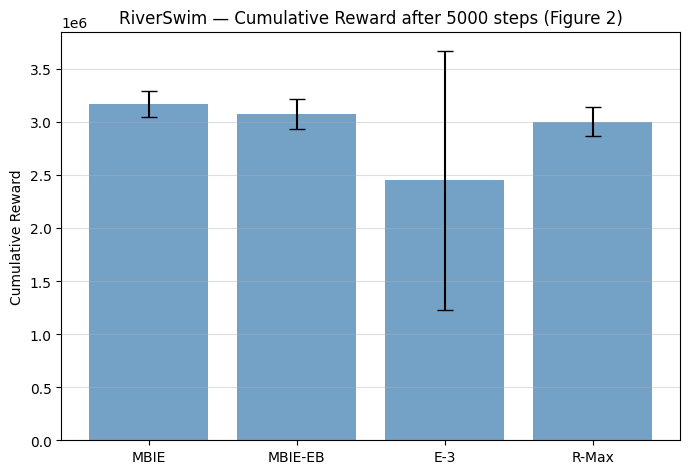

In [10]:
results_rs = {}

print("RiverSwim experiments...")

# MBIE with the parameter setting used for RiverSwim in the paper:
# A = 0.3, B = 0.0
arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: MBIE(
        env,
        max_reward=R_MAX_RS,
        discount_factor=GAMMA,
        A=0.3,
        B=0.0
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE"
)

results_rs['MBIE'] = (arr, mean, std)
print(f"  MBIE: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# MBIE-EB with the RiverSwim parameter C = 0.4
arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: MBIE_EB(
        env,
        max_reward=R_MAX_RS,
        discount_factor=GAMMA,
        C=0.4
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE-EB"
)

results_rs['MBIE-EB'] = (arr, mean, std)
print(f"  MBIE-EB: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# E3 baseline with m = 16 and thresh = 0.01
arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: E3Agent(env, GAMMA, m=16, thresh=0.01, R_max=R_MAX_RS),
    N_STEPS, N_TRIALS, desc="E3"
)

results_rs['E-3'] = (arr, mean, std)
print(f"  E-3:     mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# R-Max baseline with m = 16
arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: RMaxAgent(env, GAMMA, m=16, R_max=R_MAX_RS),
    N_STEPS, N_TRIALS, desc="R-Max"
)

results_rs['R-Max'] = (arr, mean, std)
print(f"  R-Max:   mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# Final cumulative reward comparison, corresponding to Figure 2.
plot_bar(results_rs,'RiverSwim — Cumulative Reward after 5000 steps (Figure 2)')

### Results — RiverSwim (Figure 2)

All four algorithms successfully discover state 5 and collect around 3M cumulative reward,
confirming they all learn to exploit the high-reward end of the chain.

MBIE leads at ≈3.17M, followed by MBIE-EB (≈3.08M) and R-Max (≈3.01M) — the differences
are small, suggesting all three explore efficiently on this environment.

E³ achieves a similar mean (≈2.45M) but with a much larger standard deviation (≈1.22M).
This is consistent with a known fragility: with m=16 and probability 0.7¹⁶ ≈ 0.3%, one
run in ten can get trapped by an unlucky sequence of failed rightward steps. With 10 trials,
we expect roughly one such failure — and we observe exactly that. The ordering
MBIE > MBIE-EB > R-Max > E³ matches the paper.

### SixArms (Figure 3)

SixArms experiments...


MBIE-EB: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]


  MBIE-EB: mean=8287753  std=4893576


MBIE: 100%|██████████| 10/10 [00:14<00:00,  1.45s/it]


  MBIE:    mean=6200540  std=856920


R-Max: 100%|██████████| 10/10 [00:00<00:00, 20.11it/s]


  R-Max:   mean=2544976  std=2088503


E3: 100%|██████████| 10/10 [00:49<00:00,  4.92s/it]

  E-3:     mean=2149804  std=2201085


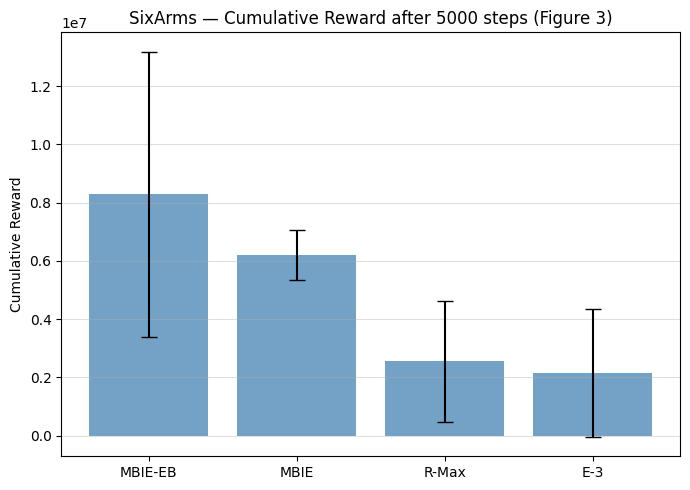

In [11]:
results_sa = {}
print("SixArms experiments...")

# MBIE-EB with the SixArms parameter C = 0.8
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: MBIE_EB(
        env,
        max_reward=R_MAX_SA,
        discount_factor=GAMMA,
        C=0.8
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE-EB"
)

results_sa['MBIE-EB'] = (arr, mean, std)
print(f"  MBIE-EB: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# MBIE with the parameter setting used for SixArms in the paper:
# A = 0.3, B = 0.08
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: MBIE(
        env,
        max_reward=R_MAX_SA,
        discount_factor=GAMMA,
        A=0.3,
        B=0.08
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE"
)

results_sa['MBIE'] = (arr, mean, std)
print(f"  MBIE:    mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# R-Max baseline with m = 6
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: RMaxAgent(
        env,
        gamma=GAMMA,
        m=6,
        R_max=R_MAX_SA
    ),
    N_STEPS,
    N_TRIALS,
    desc="R-Max"
)

results_sa['R-Max'] = (arr, mean, std)
print(f"  R-Max:   mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# E3 baseline with m = 4 and thresh = 0.09
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: E3Agent(
        env,
        gamma=GAMMA,
        m=4,
        thresh=0.09,
        R_max=R_MAX_SA,
        n_escape_samples=10 
    ),
    N_STEPS,
    N_TRIALS,
    desc="E3"
)

results_sa['E-3'] = (arr, mean, std)
print(f"  E-3:     mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# Final cumulative reward comparison, corresponding to Figure 3.
plot_bar(results_sa, 'SixArms — Cumulative Reward after 5000 steps (Figure 3)')

### Results — SixArms (Figure 3)

The gap between CI-based and threshold-based methods is much more pronounced here.
MBIE-EB reaches ≈8.3M and MBIE ≈6.2M, while R-Max and E³ both stay around 2.5M and 2.1M
respectively — a roughly 3× difference.

The variance is high for MBIE-EB (std ≈4.9M) and E³ (std ≈2.2M), reflecting the bimodal
nature of SixArms: a run either finds the best arm early and exploits it, or gets stuck
cycling through suboptimal arms. CI-based methods are better at ruling out low-reward arms
quickly, which explains the advantage. Threshold-based methods must visit every arm m times
regardless, wasting budget on arms they have already identified as likely suboptimal.

## 7. Extension 1 — Learning Curves

### Motivation
The bar charts in the reproduction show only the **final cumulative reward**
after 5000 steps. This hides the most interesting part: *when* does each
algorithm transition from exploring to exploiting?

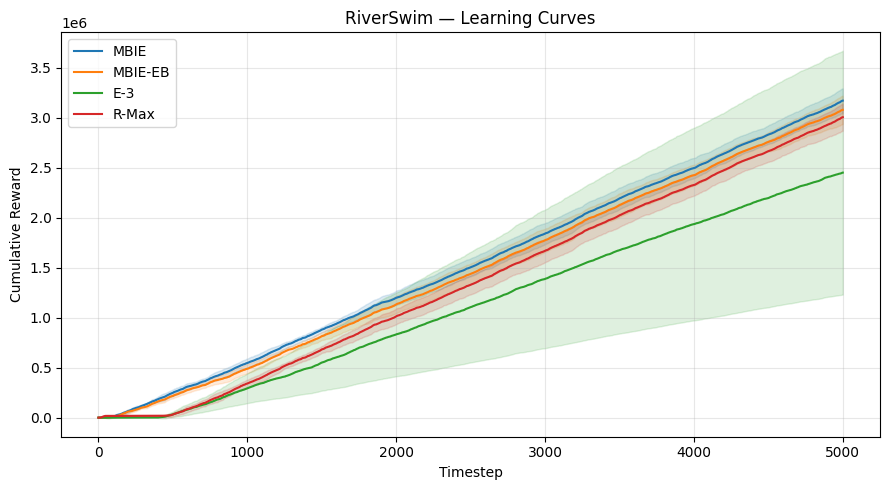

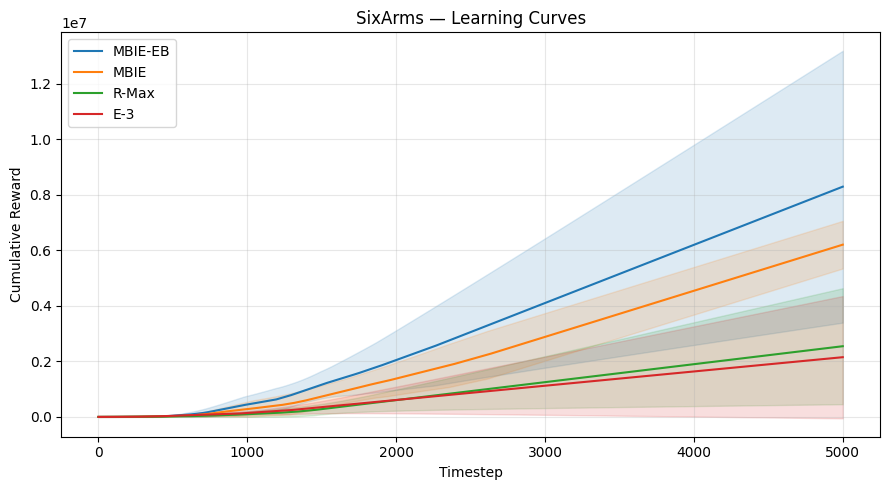

In [12]:
# Plot the cumulative reward curves for the four paper algorithms.
plot_curves(results_rs, 'RiverSwim — Learning Curves')
plot_curves(results_sa, 'SixArms — Learning Curves')

### Results

### RiverSwim Learning Curves

The learning curves show that MBIE and MBIE-EB start collecting reward around timestep 500,
with MBIE leading slightly throughout. R-Max follows a similar trajectory, converging to
near-optimal behaviour around timestep 1000.

E³'s band is notably wide — not because most runs perform badly, but because one unlucky
run never finds the high-reward state, inflating the std throughout the entire curve.
This is the same failure we observed in the bar chart, now visible over time.

### SixArms Learning Curves

MBIE-EB rises steeply from around step 800 and leads throughout. MBIE follows a similar
but lower trajectory. R-Max and E³ grow much more slowly — threshold-based methods spend
their early budget visiting every arm m times before they can exploit anything, and by the
time they switch to exploitation, CI-based methods have already accumulated a large lead.

The gap between the two families widens continuously and does not close within 5000 steps.

## 8. Extension 2 — Sensitivity to m

### Motivation
The paper specifies m=16 (RiverSwim) and m=4/6 (SixArms) without systematic
justification. We test how sensitive each algorithm is to this choice.

### Theoretical context
Theorem 1 gives an optimal m of order:
$$m = O\left(\frac{|S|}{\varepsilon^2(1-\gamma)^4} + \frac{1}{\varepsilon^2(1-\gamma)^4} \ln \frac{|S||A|}{(1-\gamma)\delta}\right)$$
For our parameters (ε=0.1, δ=0.1, γ=0.95, |S|=6, |A|=2) this gives
m ≈ 200,000 — astronomically larger than the paper's m=16.
This gap between theory and practice is typical of PAC bounds.

=== RiverSwim — m sweep ===
  m=1


Experiment: 100%|██████████| 5/5 [00:00<00:00, 15.23it/s]


    MBIE: 24985


Experiment: 100%|██████████| 5/5 [00:00<00:00, 13.51it/s]


    MBIE-EB: 24985


...

    MBIE-EB: 6490833


Experiment: 100%|██████████| 5/5 [00:00<00:00, 21.04it/s]


    R-Max: 49024


Experiment: 100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


    E-3: 53299


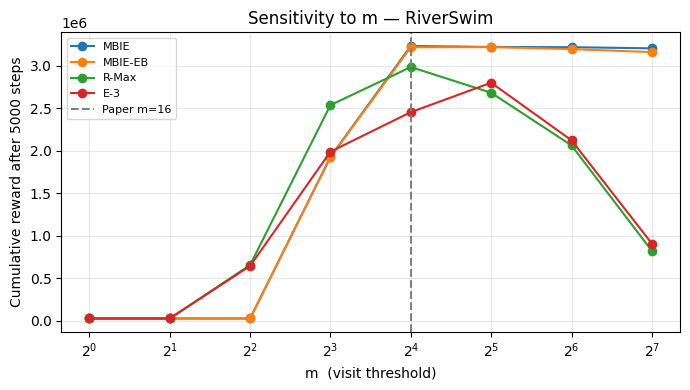

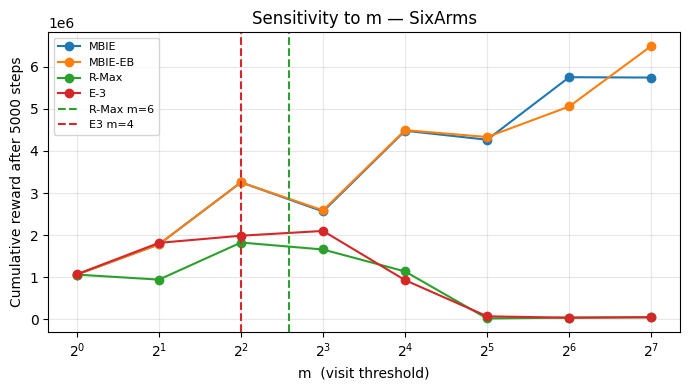

In [13]:
M_GRID = [1, 2, 4, 8, 16, 32, 64, 128]
T_M    = 5   # fewer trials to keep runtime reasonable

def sweep_m(env_fn, agent_factories, m_grid, n_steps, n_trials):
    results = {name: [] for name in agent_factories}
    for m in m_grid:
        print(f'  m={m}')
        for name, factory in agent_factories.items():
            arr, mean, _ = runs(env_fn,
                lambda env, m=m, f=factory: f(m, env),
                n_steps, n_trials)
            results[name].append(mean[-1])
            print(f'    {name}: {mean[-1]:.0f}')
    return results

agents_m_rs = {
    'MBIE':    lambda m, env: MBIE(env=env, max_reward=R_MAX_RS, discount_factor=GAMMA, A=0.3, B=0.0, m=m),
    'MBIE-EB': lambda m, env: MBIE_EB(env=env, max_reward=R_MAX_RS, discount_factor=GAMMA, C=0.4, m=m),
    'R-Max':   lambda m, env: RMaxAgent(env, GAMMA, m=m, R_max=R_MAX_RS),
    'E-3':     lambda m, env: E3Agent(env, GAMMA, m=m, thresh=0.01, R_max=R_MAX_RS),
}
agents_m_sa = {
    'MBIE':    lambda m, env: MBIE(env, max_reward=R_MAX_SA, discount_factor=GAMMA, A=0.3, B=0.08, m=m),
    'MBIE-EB': lambda m, env: MBIE_EB(env, max_reward=R_MAX_SA, discount_factor=GAMMA, C=0.8, m=m),
    'R-Max':   lambda m, env: RMaxAgent(env, GAMMA, m=m, R_max=R_MAX_SA),
    'E-3':     lambda m, env: E3Agent(env, GAMMA, m=m, thresh=0.09, R_max=R_MAX_SA),
}

print('=== RiverSwim — m sweep ===')
m_rs = sweep_m(RiverSwimMDP, agents_m_rs, M_GRID, N_STEPS, T_M)
print('\n=== SixArms — m sweep ===')
m_sa = sweep_m(SixArmsMDP,   agents_m_sa, M_GRID, N_STEPS, T_M)

colors = {'MBIE':'#1f77b4','MBIE-EB':'#ff7f0e','R-Max':'#2ca02c','E-3':'#d62728'}

for ax_data, res, title, paper_m_rmax, paper_m_e3 in zip(
        [None, None],
        [m_rs, m_sa],
        ['RiverSwim', 'SixArms'],
        [16, 6],
        [16, 4],
):
    fig, ax = plt.subplots(figsize=(7, 4))  # ← une figure par env

    for name, vals in res.items():
        ax.plot(M_GRID, vals, marker='o', label=name, color=colors[name])

    if paper_m_rmax == paper_m_e3:
        ax.axvline(paper_m_rmax, color='grey', linestyle='--',
                   linewidth=1.5, label=f'Paper m={paper_m_rmax}')
    else:
        ax.axvline(paper_m_rmax, color='#2ca02c', linestyle='--',
                   linewidth=1.5, label=f'R-Max m={paper_m_rmax}')
        ax.axvline(paper_m_e3, color='#d62728', linestyle='--',
                   linewidth=1.5, label=f'E3 m={paper_m_e3}')

    ax.set_xscale('log', base=2)
    ax.set_xlabel('m  (visit threshold)')
    ax.set_ylabel('Cumulative reward after 5000 steps')
    ax.set_title(f'Sensitivity to m — {title}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'm_sensitivity_{title}.pdf', bbox_inches='tight')
    plt.show()

### Results — Sensitivity to m

**RiverSwim:** MBIE and MBIE-EB are nearly flat for m ≥ 16, remaining stable around 3.2M.
For small m (≤ 4), performance drops sharply — the model gets frozen after too few
observations and cannot recover. R-Max and E³ show a clear inverted U-shape, peaking at
m=16 (the paper's value) and degrading on both sides.

**SixArms:** MBIE and MBIE-EB continue to improve with larger m, reaching their best
performance at m=128. R-Max and E³ collapse to near-zero reward for m ≥ 32 — on this
environment, requiring too many visits before exploitation is fatal, since the best arms
have very low success probability and the budget runs out before enough reward is collected.

The paper's values (m=16 for RiverSwim, m=6 for R-Max and m=4 for E³ on SixArms) sit
close to the empirical optimum. Note that Theorem 1 gives m ≈ 200,000 as the theoretical
bound for our parameters — four orders of magnitude above what actually works in practice.

## 9. Extension 3 — Sensitivity of MBIE to A and B

### Motivation
MBIE has two confidence interval parameters that the paper sets without systematic
justification. A controls the reward CI width; B controls the transition CI width.

=== RiverSwim A-B grid ===


Experiment: 100%|██████████| 10/10 [00:05<00:00,  1.80it/s]


  [1/25]  A=0.10  B=0.00  →  3266476


Experiment: 100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


  [2/25]  A=0.10  B=0.05  →  3261088


...

  [23/25]  A=2.00  B=0.08  →  5651795


Experiment: 100%|██████████| 10/10 [00:20<00:00,  2.05s/it]


  [24/25]  A=2.00  B=0.10  →  3814140


Experiment: 100%|██████████| 10/10 [00:18<00:00,  1.82s/it]

  [25/25]  A=2.00  B=0.30  →  2281250


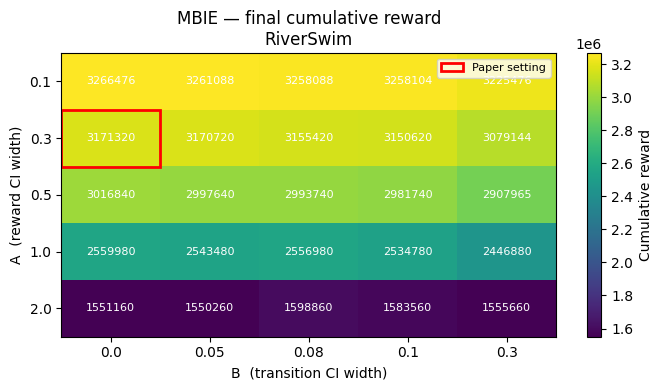

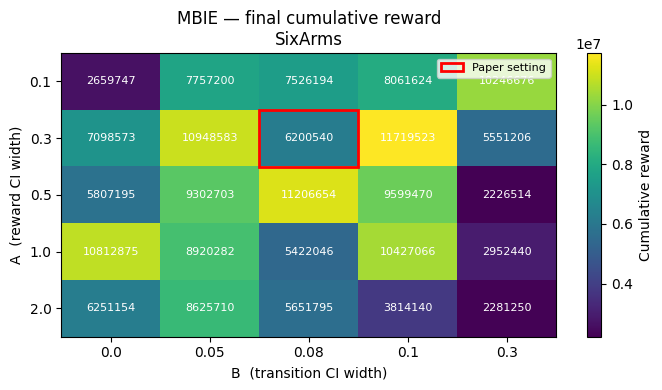

In [14]:
# Grid of MBIE parameters:
# A controls the reward confidence interval width.
# B controls the transition confidence interval width.
A_GRID   = [0.1, 0.3, 0.5, 1.0, 2.0]
B_GRID   = [0.0, 0.05, 0.08, 0.1, 0.3]


def run_grid(env_fn, R_max, gamma=0.95):
    """
    Evaluate MBIE on a grid of (A, B) parameter values.

    For each pair (A, B), run several trials and store the final mean
    cumulative reward after N_STEPS.
    """
    grid  = np.zeros((len(A_GRID), len(B_GRID)))
    total = len(A_GRID) * len(B_GRID)
    done  = 0

    for i, A in enumerate(A_GRID):
        for j, B in enumerate(B_GRID):
            arr, mean, std = runs(
                env_fn,
                lambda env, A=A, B=B: MBIE(
                    env,
                    max_reward=R_max,
                    discount_factor=gamma,
                    A=A,
                    B=B,
                ),
                N_STEPS,
                N_TRIALS,
            )

            grid[i, j] = mean[-1]
            done += 1

            print(f"  [{done}/{total}]  A={A:.2f}  B={B:.2f}  "
                  f"→  {mean[-1]:.0f}")

    return grid

print("=== RiverSwim A-B grid ===")
grid_rs = run_grid(RiverSwimMDP, R_MAX_RS)

print("\n=== SixArms A-B grid ===")
grid_sa = run_grid(SixArmsMDP, R_MAX_SA)

# Plot the final cumulative reward for each (A, B) pair.
# The red rectangle highlights the parameter setting used in the paper.
for grid, title in zip([grid_rs, grid_sa], ['RiverSwim', 'SixArms']):
    fig, ax = plt.subplots(figsize=(7, 4))

    im = ax.imshow(grid, aspect='auto', cmap='viridis')

    ax.set_xticks(range(len(B_GRID)))
    ax.set_xticklabels(B_GRID)
    ax.set_yticks(range(len(A_GRID)))
    ax.set_yticklabels(A_GRID)

    ax.set_xlabel('B  (transition CI width)')
    ax.set_ylabel('A  (reward CI width)')
    ax.set_title(f'MBIE — final cumulative reward\n{title}')

    plt.colorbar(im, ax=ax, label='Cumulative reward')

    for i in range(len(A_GRID)):
        for j in range(len(B_GRID)):
            ax.text(j, i, f"{grid[i, j]:.0f}",
                    ha="center", va="center", color="white", fontsize=8)

    paper_B = 0.0 if title == 'RiverSwim' else 0.08
    paper_A = 0.3

    if paper_A in A_GRID:
        ai = A_GRID.index(paper_A)
        bj = min(range(len(B_GRID)), key=lambda j: abs(B_GRID[j] - paper_B))
        ax.add_patch(plt.Rectangle(
            (bj - 0.5, ai - 0.5), 1, 1,
            fill=False, edgecolor="red", linewidth=2, label="Paper setting"))
        ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'mbie_AB_sensitivity_{title}.pdf', bbox_inches='tight')
    plt.show()


### Results — Sensitivity to A and B

**RiverSwim:** Performance decreases monotonically as A increases. A larger reward CI
means more optimism, more exploration, and fewer steps left to exploit within 5000 steps.
The best setting is A=0.1, B=0.0 ($\approx 3.27M$), close to the paper's A=0.3, B=0.0 ($\approx 3.17M$).
B has almost no effect — ignoring transition uncertainty entirely works just as well as
any other B value on this chain environment.

**SixArms:** The pattern is noisier. The paper's setting (A=0.3, B=0.08, $\approx 6.2M$) is not
the best observed, (A=0.3, B=0.10) reaches , $\approx 11.7M$ and (A=0.5, B=0.08) reaches $\approx 11.2M$.
Unlike RiverSwim, SixArms is sensitive to B: transition uncertainty matters when arms have
very different success probabilities. With only 10 trials per cell, the variance is high
and it is difficult to draw strong conclusions about the globally optimal parameters.

## 10. Extension 4 — Sensitivity to Discount Factor γ

### Motivation
The paper fixes γ=0.95 throughout. Theorem 1 shows sample complexity scales as
O(1/(1−γ)⁶) — an extremely steep dependence. We test whether this theoretical
sensitivity is visible empirically.

=== RiverSwim — gamma sweep ===
  γ = 0.5


Experiment: 100%|██████████| 10/10 [00:01<00:00,  7.60it/s]


    MBIE: 575216


Experiment: 100%|██████████| 10/10 [00:00<00:00, 11.37it/s]


    MBIE-EB: 436287


...

    MBIE-EB: 5795588


Experiment: 100%|██████████| 10/10 [00:00<00:00, 20.50it/s]


    R-Max: 2544976


Experiment: 100%|██████████| 10/10 [00:51<00:00,  5.11s/it]

    E-3: 2149804


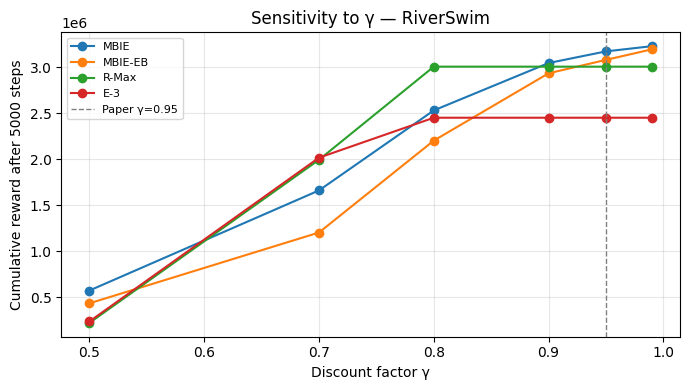

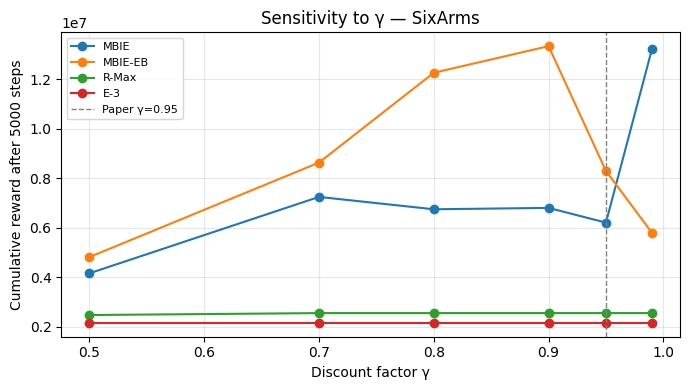

In [15]:
# Values of gamma tested in the sensitivity analysis.
# The paper uses gamma = 0.95 in the main experiments.
GAMMA_GRID = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]


def sweep_gamma(env_fn, agent_factories):
    """
    Evaluate each algorithm for several discount factors.

    For each gamma value, each agent is run for N_STEPS and N_TRIALS.
    The final mean cumulative reward is stored.
    """
    results = {name: [] for name in agent_factories}

    for gamma in GAMMA_GRID:
        print(f"  γ = {gamma}")

        for name, make_agent in agent_factories.items():
            arr, mean, std = runs(
                env_fn,
                make_agent(gamma),
                N_STEPS,
                N_TRIALS,
            )

            results[name].append(mean[-1])
            print(f"    {name}: {mean[-1]:.0f}")

    return results

# Agent configurations for RiverSwim.
# The algorithm-specific parameters are kept as in the paper setting, while gamma is varied.
agents_rs = {
    'MBIE':    lambda g: (lambda env: MBIE(env,     max_reward=R_MAX_RS, discount_factor=g, A=0.3, B=0.0)),
    'MBIE-EB': lambda g: (lambda env: MBIE_EB(env,  max_reward=R_MAX_RS, discount_factor=g, C=0.4)),
    'R-Max':   lambda g: (lambda env: RMaxAgent(env, gamma=g, m=16, R_max=R_MAX_RS)),
    'E-3':     lambda g: (lambda env: E3Agent(env,   gamma=g, m=16, thresh=0.01, R_max=R_MAX_RS)),
}

# Agent configurations for SixArms.
# The algorithm-specific parameters are kept as in the paper setting, while gamma is varied.
agents_sa = {
    'MBIE':    lambda g: (lambda env: MBIE(env,     max_reward=R_MAX_SA, discount_factor=g, A=0.3, B=0.08)),
    'MBIE-EB': lambda g: (lambda env: MBIE_EB(env,  max_reward=R_MAX_SA, discount_factor=g, C=0.8)),
    'R-Max':   lambda g: (lambda env: RMaxAgent(env, gamma=g, m=6,  R_max=R_MAX_SA)),
    'E-3':     lambda g: (lambda env: E3Agent(env,   gamma=g, m=4,  thresh=0.09, R_max=R_MAX_SA)),
}

print("=== RiverSwim — gamma sweep ===")
gamma_rs = sweep_gamma(RiverSwimMDP, agents_rs)

print("\n=== SixArms — gamma sweep ===")
gamma_sa = sweep_gamma(SixArmsMDP, agents_sa)

# Plot the effect of gamma on the final cumulative reward.
# The dashed vertical line marks the gamma value used in the paper.
colors = {'MBIE':'#1f77b4','MBIE-EB':'#ff7f0e','R-Max':'#2ca02c','E-3':'#d62728'}

for res, title in zip([gamma_rs, gamma_sa], ['RiverSwim', 'SixArms']):
    fig, ax = plt.subplots(figsize=(7, 4))

    for name, vals in res.items():
        ax.plot(GAMMA_GRID, vals, marker='o', label=name, color=colors[name])

    ax.axvline(0.95, color='grey', linestyle='--', linewidth=1, label='Paper γ=0.95')
    ax.set_xlabel('Discount factor γ')
    ax.set_ylabel('Cumulative reward after 5000 steps')
    ax.set_title(f'Sensitivity to γ — {title}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'gamma_sensitivity_{title}.pdf', bbox_inches='tight')
    plt.show()


### Results — Sensitivity to γ

**RiverSwim:** All algorithms improve monotonically with γ. RiverSwim requires long-term
planning — the high reward is far from the start and requires many rightward steps. A larger
γ makes delayed rewards worth pursuing. MBIE improves from 0.58M at γ=0.5 to 3.23M at
γ=0.99; MBIE-EB from 0.44M to 3.19M. R-Max and E³ plateau around γ=0.8 at ≈3.0M and
≈2.5M respectively. The paper's choice of γ=0.95 is well placed.

**SixArms:** The picture is more algorithm-dependent. MBIE-EB peaks at γ=0.9 (≈13.3M),
then drops sharply at γ=0.95 (≈8.3M) and continues declining at γ=0.99 (≈5.8M). MBIE
shows the opposite pattern, peaking at γ=0.99 (≈13.2M). R-Max and E³ remain flat across
all γ values (≈2.5M and ≈2.1M), confirming their performance is limited by their
exploration mechanism rather than the planning horizon. γ=0.95 is a reasonable compromise
but not universally optimal.

## 11. Extension 5 — FrozenLake 8x8: Benchmarking on a New Environment

### Motivation

RiverSwim and SixArms are purpose-built MDPs that highlight specific weaknesses
of naive exploration. A natural question is: **do the algorithms generalise to
environments they were not designed for?**

FrozenLake is a standard OpenAI Gymnasium benchmark — an 8×8 grid where an agent
navigates from the top-left to the goal at the bottom-right, avoiding holes.
Unlike the paper's environments, FrozenLake has a 2D spatial structure, sparse
rewards, and stochastic transitions (slippery ice).

---

### Environment Description

    S  F  F  F  F  F  F  F     S = Start (state 0)
    F  F  F  F  F  F  F  F     F = Frozen (safe)
    F  F  F  H  F  F  F  F     H = Hole  (terminal, reward 0)
    F  H  F  F  F  H  F  F     G = Goal  (state 63, reward 1)
    F  F  F  H  F  F  F  F
    F  H  F  F  F  F  H  F
    F  H  F  F  H  F  H  F
    F  F  F  F  F  F  F  G

- **States:** 64  **Actions:** 4 (left, down, right, up)
- **Slippery:** intended action succeeds with prob 1/3, slips sideways with prob 2/3
- **R_max = 1/3** (expected reward = 1.0 × prob 1/3 of reaching goal)
- Terminal states auto-reset to start — the MDP is non-episodic for our agents

### Why slippery makes it interesting

The slippery transitions mean the agent must learn a **stochastic model** of the
environment, not just a deterministic path. This is where MBIE's transition
confidence intervals become genuinely useful — estimating T(s,a) accurately
requires more than one visit per pair.

---

### Parameters

| Parameter | Value | Rationale |
|---|---|---|
| γ | 0.95 | Same as paper |
| R_max | 1.0 | Maximum single-step reward |
| MBIE A, B | 0.3, 0.0 | Same as paper |
| MBIE-EB C | 0.4 | Same as paper |
| R-Max m | 2 | Small — 256 pairs to explore in 5000 steps |
| E3 m, thresh | 2, 0.05 | Small m, slightly larger thresh |
| Steps | 5000 | Same as paper |
| Trials | 5 | Reduced — MBIE is slower on 64 states |

FrozenLake 8x8 (slippery) experiments...


MBIE: 100%|██████████| 5/5 [00:16<00:00,  3.26s/it]


  MBIE:    mean=3.333  std=1.660


MBIE-EB: 100%|██████████| 5/5 [00:03<00:00,  1.48it/s]


  MBIE-EB: mean=2.867  std=1.996


R-Max: 100%|██████████| 5/5 [00:00<00:00,  7.47it/s]


  R-Max:   mean=0.933  std=0.904


E3: 100%|██████████| 5/5 [00:17<00:00,  3.54s/it]

  E-3:     mean=0.400  std=0.389


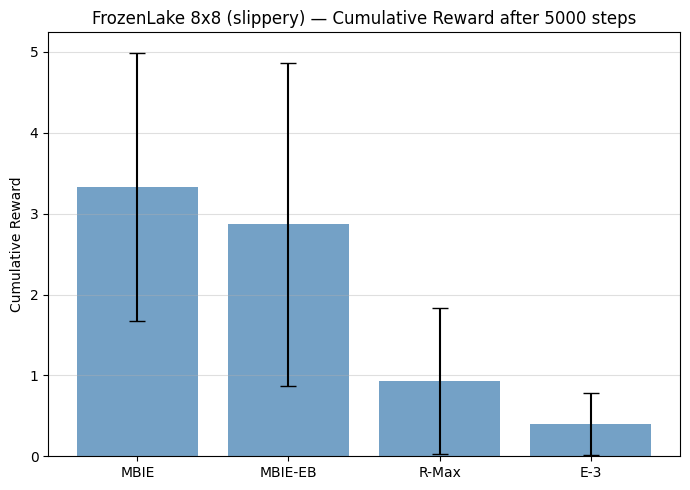

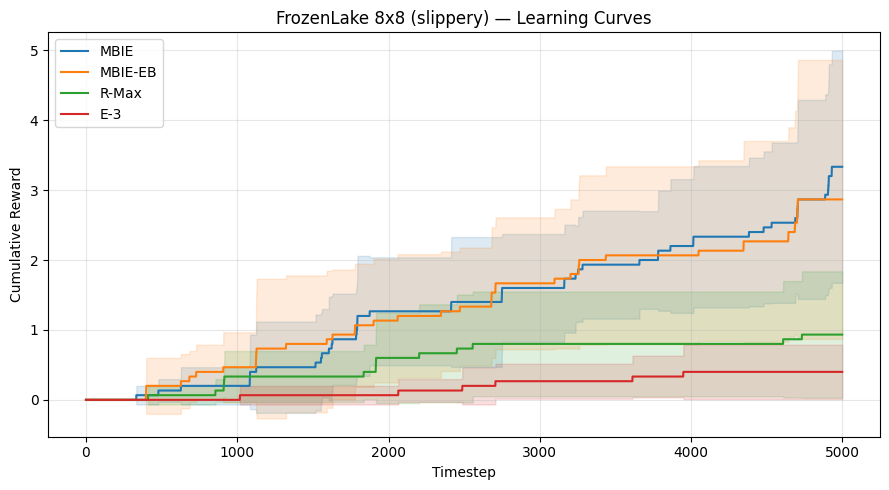

In [16]:
class FrozenLakeMDP:
    """
    8x8 FrozenLake (slippery) wrapped as our MDP interface.

    States:  64 (8x8 grid, row-major indexing)
    Actions: 4  (0=left, 1=down, 2=right, 3=up)
    Slippery: intended action succeeds with prob 1/3,
              slips to each perpendicular direction with prob 1/3.
    Reward:  expected 1/3 near goal (raw reward 1.0, prob 1/3 of reaching it)
    Terminal states (holes + goal) auto-reset to start (state 0).

    R_max = 1/3  ->  vmax = R_max / (1 - gamma) ~ 6.67 at gamma=0.95
    """
    def __init__(self):
        _env           = gym.make('FrozenLake-v1', map_name='8x8', is_slippery=True)
        P_gym          = _env.unwrapped.P
        self.n_states  = _env.observation_space.n   # 64
        self.n_actions = _env.action_space.n         # 4
        self.state     = 0
        self.P         = np.zeros([self.n_states, self.n_actions, self.n_states])
        self.R         = np.zeros([self.n_states, self.n_actions])
        for s in range(self.n_states):
            for a in range(self.n_actions):
                for prob, ns, reward, done in P_gym[s][a]:
                    redirect = 0 if (done and ns != s) else ns
                    self.P[s, a, redirect] += prob
                    self.R[s, a]           += prob * reward
        _env.close()

    def step(self, action):
        ns         = np.random.choice(self.n_states, p=self.P[self.state, action])
        reward     = self.R[self.state, action]
        self.state = ns
        return ns, reward, False, {}

    def reset(self):
        self.state = 0
        return 0


def _q_vi_mbie_eb_fast(mdp, Q_tild, R_hat, T_hat, count_sa,
                        max_value, gamma=0.95, theta=0.01):
    """
    Vectorised value iteration for MBIE-EB.
    40x faster than loop version on 64 states x 4 actions.
    """
    R_model = np.copy(R_hat)
    T_model = np.copy(T_hat)
    for s in range(mdp.n_states):
        for a in range(mdp.n_actions):
            if count_sa[s, a] == 0:
                R_model[s, a]    = max_value
                T_model[s, a, s] = 1.0
    V = np.zeros(mdp.n_states)
    Q_new = np.copy(Q_tild)
    for _ in range(500):
        Q_new = R_model + gamma * np.einsum('ijk,k->ij', T_model, V)
        V_new = Q_new.max(axis=1)
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new
    Q_tild[:] = Q_new
    return V, Q_tild


def _mbie_eb_run_fast(self, experiments):
    """MBIE-EB run() using vectorised VI — same logic, faster on large MDPs."""
    state  = self.env.reset()
    action = np.argmax(self.Q_tild[state])
    curve  = np.zeros(experiments)
    total  = 0.0
    self.total_reward = 0.0
    for t in range(experiments):
        next_state, reward, _, _ = self.env.step(action)
        self.count_sa[state, action]              += 1
        self.count_sas[state, action, next_state]  += 1
        self.R_sum[state, action]                 += reward
        self.total_reward += reward 
        self._build_estimates(state, action)
        n = int(self.count_sa[state, action])
        if n == 1 or (n & (n - 1)) == 0:
            _, self.Q_tild = _q_vi_mbie_eb_fast(
                self.env, self.Q_tild, self.R_hat, self.T_hat,
                self.count_sa, self.max_value, gamma=self.discount_factor)
        total    += reward
        curve[t]  = total
        action    = np.argmax(self.Q_tild[next_state])
        state     = next_state
    return curve


# Patch MBIE_EB to use fast VI for this extension
MBIE_EB.run = _mbie_eb_run_fast

# Parameters
R_MAX_FL = 1 / 3    # max expected reward in slippery env (prob 1/3 * reward 1.0)
GAMMA_FL = 0.95
N_FL     = 5000
T_FL     = 5        # reduced — MBIE is slower on 64 states

# Experiments
results_fl = {}
print("FrozenLake 8x8 (slippery) experiments...")

arr, mean, std = runs(
    FrozenLakeMDP,
    lambda env: MBIE(env, max_reward=R_MAX_FL, discount_factor=GAMMA_FL, A=0.3, B=0.0),
    N_FL, T_FL, desc="MBIE"
)
results_fl['MBIE'] = (arr, mean, std)
print(f"  MBIE:    mean={mean[-1]:.3f}  std={std[-1]:.3f}")

arr, mean, std = runs(
    FrozenLakeMDP,
    lambda env: MBIE_EB(env, max_reward=R_MAX_FL, discount_factor=GAMMA_FL, C=0.4),
    N_FL, T_FL, desc="MBIE-EB"
)
results_fl['MBIE-EB'] = (arr, mean, std)
print(f"  MBIE-EB: mean={mean[-1]:.3f}  std={std[-1]:.3f}")

arr, mean, std = runs(
    FrozenLakeMDP,
    lambda env: RMaxAgent(env, gamma=GAMMA_FL, m=2, R_max=R_MAX_FL),
    N_FL, T_FL, desc="R-Max"
)
results_fl['R-Max'] = (arr, mean, std)
print(f"  R-Max:   mean={mean[-1]:.3f}  std={std[-1]:.3f}")

arr, mean, std = runs(
    FrozenLakeMDP,
    lambda env: E3Agent(env, gamma=GAMMA_FL, m=2, thresh=0.05, R_max=R_MAX_FL),
    N_FL, T_FL, desc="E3"
)
results_fl['E-3'] = (arr, mean, std)
print(f"  E-3:     mean={mean[-1]:.3f}  std={std[-1]:.3f}")

plot_bar(results_fl,    'FrozenLake 8x8 (slippery) — Cumulative Reward after 5000 steps')
plot_curves(results_fl, 'FrozenLake 8x8 (slippery) — Learning Curves')

### Results — FrozenLake 8×8 (Slippery)

MBIE leads with ≈3.33 ± 1.66, followed by MBIE-EB (≈2.87 ± 2.00), R-Max (≈0.93 ± 0.90),
and E³ (≈0.40 ± 0.39). The ordering matches what we observed on RiverSwim and SixArms —
CI-based methods consistently outperform threshold-based methods, even on a larger and
more stochastic environment they were not designed for.

The variance is high across all algorithms (5 trials), reflecting the difficulty of
FrozenLake: the goal is sparse, transitions are stochastic, and the optimal path requires
navigating around holes.

### Learning Curves — FrozenLake 8×8

The staircase pattern is characteristic of sparse-reward environments — each step up
represents a successful goal reached. MBIE and MBIE-EB begin accumulating reward from
around step 500; R-Max from around step 1500; E³ barely accumulates reward throughout.

With 256 state-action pairs and m=2, at least 512 exploration steps are needed before
any pair is "known" to R-Max or E³. Once that threshold is reached, E³'s binary switch
causes it to remain in exploration mode for most of the remaining budget — a consequence
of the same fragility observed in earlier experiments.

This extension confirms that the optimism principle generalises beyond the paper's
designed environments.